In [2]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random

### Hyperparameters

In [4]:
# the number of objects in each world
WORLD_SIZE = 5

# the dimension of the feature vector of each object
# as produced by the encoder
OBJECT_FEATURE_DIMENSION = 6

# the dimension of the speaker's generated vector representation
NEURALESE_DIMENSION = 12

### Model Components

In [5]:
class ObjectEncoder(nn.Module):
    """
    Encodes a single (3x3) Object into a feature vector
    Input     : [[001][100][010]] or Purple-Cirle-No-Outline. See metadata.json
    InputSize : (3,3)
    OutputSize: (OBJECT_FEATURE_DIMENSION)
    """
    def __init__(self, output_dimension=OBJECT_FEATURE_DIMENSION):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 4, kernel_size=2),  # → (batch, 4, 2, 2)
            nn.Flatten(),                    # → (batch, 16)
            nn.Linear(16, output_dimension)
        )

    def forward(self, x):
        return self.encoder(x)

In [6]:
class Speaker(nn.Module):
    """
    Transforms the encoded objects in world W + boolean inclusion mask for target subset X
    into a representative vector.

    InputSize : (WORLD_SIZE * OBJECT_FEATURE_DIMENSION) + WORLD_SIZE)
    OutputSize: (NEURALESE_DIMENSION)
    """
    def __init__(self, input_dimension=(WORLD_SIZE * OBJECT_FEATURE_DIMENSION) + WORLD_SIZE,
                 output_dimension=NEURALESE_DIMENSION):
        super().__init__()
        self.speaker_net = nn.Sequential(
            nn.Linear(input_dimension, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dimension)
        )

    def forward(self, x):
        return self.speaker_net(x)

In [7]:
class Listener(nn.Module):
    """
    Takes the resultant vector from the speaker, along with W_i (an element of the world W)
    and predicts whether this element belongs to X, the target subset.

    InputSize : (NEURALESE_DIMENSION + OBJECT_FEATURE_DIMENSION)
    OutputSize: (1) -> logit for binary classification
    """
    def __init__(self, input_dimension=NEURALESE_DIMENSION + OBJECT_FEATURE_DIMENSION,
                 output_dimension=1):
        super().__init__()
        self.listener_net = nn.Sequential(
            nn.Linear(input_dimension, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, output_dimension)
        )

    def forward(self, x):
        return self.listener_net(x)


In [8]:
class SpeakerListenerSystem(nn.Module):
    """
    The end-to-end system.
    Encoder -> Speaker -> Listener
    """
    def __init__(self, world_size, feature_dimension, neuralese_dimension):
        super().__init__()

        self.world_size          = world_size
        self.feature_dimension   = feature_dimension
        self.neuralese_dimension = neuralese_dimension

        speaker_input_size  = (self.world_size * self.feature_dimension) + self.world_size
        listener_input_size = self.neuralese_dimension + self.feature_dimension

        self.encoder  = ObjectEncoder(output_dimension=self.feature_dimension)
        self.speaker  = Speaker(input_dimension=speaker_input_size, output_dimension=neuralese_dimension)
        self.listener = Listener(input_dimension=listener_input_size, output_dimension=1)


    def forward(self, W, X_mask, return_neuralese_only=False):
        """
        W:      A batch of worlds.
                Each world is a set of (3x3) objects.
                Tensor of shape (batch_size, world_size, 3, 3).

        X_mask: A batch of boolean masks
                Each value indicated whether the object at that index in W
                is included in the target subset X
                Tensor of shape (batch_size, world_size)
        """
        batch_size = W.shape[0]

        ### STEP 1: Encode all objects in the world
        # Reshape for batch processing ny the encoder (B, 5, 3, 3) -> (B*5, 1, 3, 3)
        W_flat = W.view(-1, 1, 3, 3)
        # Get features for all objects: (B*5, feature_dim)
        object_features_flat = self.encoder(W_flat)
        # Reshape back to per-batch item:(B, 5, feature_dim)
        object_features = object_features_flat.view(batch_size, self.world_size, self.feature_dimension)


        ### STEP 2: Assemble the inputs to the speaker model
        # Flatten object features: (B, 5, feature_dim) -> (B, 5*feature_dim)
        V_W =  object_features.view(batch_size, -1)
        # Create the indicator mask
        M_X = X_mask
        # Concatenate features and mask
        speaker_input = torch.cat([V_W, M_X], dim=1)


        ### STEP 3: Speaker generates neuralese
        # representation has shape (B, neuralese_dimension)
        representation = self.speaker(speaker_input)

        if return_neuralese_only:
            return representation

        ### STEP 4: Prepare the listener's input
        # The listener needs to pair the speaker's representation with each object feature
        # Expand the representation to match the number of objects
        # (B, rep_dim) -> (B, 1, rep_dim) -> (B, world_size, rep_dim)
        r_expanded = representation.unsqueeze(1).repeat(1, self.world_size, 1)
        # Concatenate with object features: (B, 5, rep_dim) + (B, 5, feature_dim)
        listener_input = torch.cat([r_expanded, object_features], dim=2)


        ### STEP 5: Shuffle inputs to the listener
        # This is to avoid the speaker simply learning to tell the listener about X_mask
        # without learning anything about the objects in X themselves.
        # Create a random permutation for each item in the batch
        shuffled_indices = [torch.randperm(self.world_size) for _ in range(batch_size)]
        # Apply the shuffle
        shuffled_input   = torch.stack([features[p] for features, p in zip(listener_input, shuffled_indices)])
        shuffled_labels  = torch.stack([labels[p]   for labels,   p in zip(X_mask, shuffled_indices)])


        ### STEP 6: Listener makes an inclusion prediction for each object
        # Reshape for batch processing by the listener
        # (B, 5, rep_dim + feature_dim) -> (B*5, rep_dim + feature_dim)
        listener_input_flat = shuffled_input.view(-1, self.neuralese_dimension + self.feature_dimension)
        # Get predictions (logits) -> (B*5, 1)
        predictions_flat = self.listener(listener_input_flat)
        # Reshape back to (B, world_size)
        predictions = predictions_flat.view(batch_size, self.world_size)

        return predictions, shuffled_labels

### Data Loading

In [9]:
def generate_batch(batch_size, world_size):
    """Generates a batch of dummy data"""

    # Random 3x3 objects for the world
    W_batch = torch.rand(batch_size, world_size, 3, 3)

    # Random binary masks
    X_mask_batch = torch.randint(0, 2, (batch_size, world_size)).float()

    # Ensure at least one object is selected in each world
    for i in range(batch_size):
        if X_mask_batch[i].sum() == 0:
            # Randomly select one object
            X_mask_batch[i, random.randint(0, world_size-1)] = 1.0


    return W_batch, X_mask_batch

In [10]:
def load_dataset(path='dataset.npz'):
    """Load the real dataset from npz file"""

    data = np.load(path, allow_pickle=True)

    W = data['W']
    X_mask = data['X_mask']
    rule_encodings = data['rule_encodings']
    rule_texts = data['rule_texts']

    # Load metadata
    metadata_path = path.replace('.npz', '_metadata.json')
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)

    return W, X_mask, rule_encodings, rule_texts, metadata

In [11]:
def split_dataset(W, X_mask, rule_encodings, rule_texts,
                speaker_listener_ratio=0.5,
                translator_train_ratio=0.4,
                translator_test_ratio =0.1,
                seed=42):

    """
    Split dataset into three portions with shuffling:
    1. Speaker-Listener training (50%)
    2. Translator training (40%)
    3. Translator testing (10%)

    Args:
        W: World matrices [N, 5, 3, 3]
        X_mask: Subset masks [N, 5]
        rule_encodings: Rule encodings [N, ...]
        rule_texts: Rule text strings [N]
        speaker_listener_ratio: Fraction for speaker-listener
        translator_train_ratio: Fraction for translator training
        translator_test_ratio: Fraction for translator testing
        seed: Random seed for reproducibility

    Returns:
        Dictionary with all splits
    """

    assert abs(speaker_listener_ratio + translator_train_ratio + translator_test_ratio - 1.0) < 1e-6, \
           "Ratios must sum to 1.0"
    np.random.seed(seed)

    # Shuffle the dataset
    N_total = len(W)
    indices = np.random.permutation(N_total)

    # Calculate sizes of data portions
    speaker_listener_size = int(N_total * speaker_listener_ratio)
    translator_train_size = int(N_total * translator_train_ratio)
    translator_test_size  = int(N_total * translator_test_ratio)

    # Calculate indices for splitting
    speaker_listener_idx = indices[:speaker_listener_size]
    translator_train_idx = indices[speaker_listener_size:speaker_listener_size + translator_train_size]
    translator_test_idx  = indices[speaker_listener_size + translator_train_size:]

    # Split the data
    split_dataset = {
        'speaker_listener': {
            'W':              torch.tensor(W[speaker_listener_idx]).float(),
            'X_mask':         torch.tensor(X_mask[speaker_listener_idx]).float(),
            'rule_encodings': rule_encodings[speaker_listener_idx],
            'rule_texts':     rule_texts[speaker_listener_idx]
        },
        'translator_train': {
            'W':              torch.tensor(W[translator_train_idx]).float(),
            'X_mask':         torch.tensor(X_mask[translator_train_idx]).float(),
            'rule_encodings': rule_encodings[translator_train_idx],
            'rule_texts':     rule_texts[translator_train_idx]
        },
        'translator_test': {
            'W':              torch.tensor(W[translator_test_idx]).float(),
            'X_mask':         torch.tensor(X_mask[translator_test_idx]).float(),
            'rule_encodings': rule_encodings[translator_test_idx],
            'rule_texts':     rule_texts[translator_test_idx]
        }
    }

    print("Dataset Split:")
    print(f"  Speaker-Listener:  {len(speaker_listener_idx):,} ({speaker_listener_ratio*100:.0f}%)")
    print(f"  Translator Train:  {len(translator_train_idx):,} ({translator_train_ratio*100:.0f}%)")
    print(f"  Translator Test:   {len(translator_test_idx):,}  ({translator_test_ratio*100:.0f}%)")
    print(f"  Total:             {N_total:,}")

    return split_dataset

In [13]:
# Load dataset and split
W_data, X_mask_data, rule_encodings_data, rule_texts_data, metadata = load_dataset('../data/dataset.npz')
dataset_splits = split_dataset(W_data, X_mask_data, rule_encodings_data, rule_texts_data)

def load_batch(split_name, start_idx, batch_size, include_rules=False):
    """Load a batch of data from the specified split"""
    split = dataset_splits[split_name]
    end_idx = start_idx + batch_size

    Wb = split['W'][start_idx:end_idx]
    Xb = split['X_mask'][start_idx:end_idx]

    if include_rules:
        rb = split['rule_tokens'][start_idx:end_idx]
        return Wb, Xb, rb

    return Wb, Xb

Dataset Split:
  Speaker-Listener:  852,916 (50%)
  Translator Train:  682,333 (40%)
  Translator Test:   170,584  (10%)
  Total:             1,705,833


### Visualizations

In [14]:
def plot_metric(values, step_size, metric_name, save_path=None, figsize=(10,6)):
    """
    Plot training metric (loss or accuracy) over epochs

    Args:
        values: List or array of metric values recorded during training
        step_size: Number of epochs between each recorded value (e.g., 50 if you log every 50 epochs)
        metric_name: Name of the metric for labels (e.g., 'Loss', 'Accuracy')
        save_path: Optional path to save the figure (e.g., 'speaker_loss.png')
        figsize: Tuple specifying figure size (width, height)

    Example:
        plot_metric(losses, 50, 'Loss', save_path='speaker_loss.png')
        plot_metric(accuracies, 50, 'Accuracy', save_path='speaker_accuracy
    """

    # Calculate epochs based on step size
    epochs = np.arange(step_size, len(values)*step_size + 1, step_size)

    # Create the plot
    plt.figure(figsize=figsize)
    plt.plot(epochs, values, linewidth=2, color="#B41F1F" if 'loss' in metric_name.lower() else "#35B457")

    # Styling
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel(metric_name, fontsize=12)
    plt.title(f'{metric_name} over Training', fontsize=14)

    # Tight layout for better spacing
    plt.tight_layout()

    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")

    plt.show()

## The  Speaker Listener

### Training

In [15]:
# Hyperparameters for training
BATCH_SIZE    = 32 # 32
NUM_EPOCHS    = 2  # 10
LEARNING_RATE = 1e-4

In [16]:
# Instantiate the system
model = SpeakerListenerSystem(
    world_size          = WORLD_SIZE,
    feature_dimension   = OBJECT_FEATURE_DIMENSION,
    neuralese_dimension = NEURALESE_DIMENSION,
)

# Use BCEWithLogitsLoss because our model outputs raw logits (more stable)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [17]:

step = 0
start_index = 0
N_DATA = len(dataset_splits['speaker_listener']['W'])

losses = []
accuracies = []

print("Starting speaker-listener training...")
for epoch in range(NUM_EPOCHS):
    start_index = 0

    # Stop when we run out of data
    while start_index < N_DATA:
        batch_size = min(BATCH_SIZE, N_DATA - start_index)

        # Load a batch of speaker-listener training data
        W, X_mask = load_batch('speaker_listener', start_index, batch_size)
        start_index += BATCH_SIZE
        step += 1

        # Forward pass - y_truth is the shuffled X_mask
        optimizer.zero_grad()
        y_logits, y_truth = model(W, X_mask)

        # Calculate loss - (y_truth serves as the ground truth)
        loss = criterion(y_logits, y_truth)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        if (step + 1) % 500 == 0:
            # Track data consumption
            print(f"Epoch: {epoch}. start_index: {start_index}, end_index: {start_index + batch_size}")

            # Calculate accuracy for monitoring
            preds    = torch.sigmoid(y_logits) > 0.5
            accuracy = (preds.float() == y_truth).float().mean()
            print(f"Step [{step+1}/{NUM_EPOCHS * (N_DATA // BATCH_SIZE) + 1}], Loss: {loss.item():.4f}, Accuracy: {accuracy.item():.4f}")

            # Store metrics
            losses.append(loss.item())
            accuracies.append(accuracy.item())

print("Training finished.")

Starting speaker-listener training...
Epoch: 0. start_index: 15968, end_index: 16000
Step [500/53307], Loss: 0.6151, Accuracy: 0.6812
Epoch: 0. start_index: 31968, end_index: 32000
Step [1000/53307], Loss: 0.6032, Accuracy: 0.6812
Epoch: 0. start_index: 47968, end_index: 48000
Step [1500/53307], Loss: 0.6071, Accuracy: 0.6750
Epoch: 0. start_index: 63968, end_index: 64000
Step [2000/53307], Loss: 0.5922, Accuracy: 0.6938
Epoch: 0. start_index: 79968, end_index: 80000
Step [2500/53307], Loss: 0.5919, Accuracy: 0.6938
Epoch: 0. start_index: 95968, end_index: 96000
Step [3000/53307], Loss: 0.5969, Accuracy: 0.6875
Epoch: 0. start_index: 111968, end_index: 112000
Step [3500/53307], Loss: 0.6128, Accuracy: 0.6625
Epoch: 0. start_index: 127968, end_index: 128000
Step [4000/53307], Loss: 0.5688, Accuracy: 0.7063
Epoch: 0. start_index: 143968, end_index: 144000
Step [4500/53307], Loss: 0.5365, Accuracy: 0.7563
Epoch: 0. start_index: 159968, end_index: 160000
Step [5000/53307], Loss: 0.4498, Ac

Plot saved to ../images/speaker_loss.png


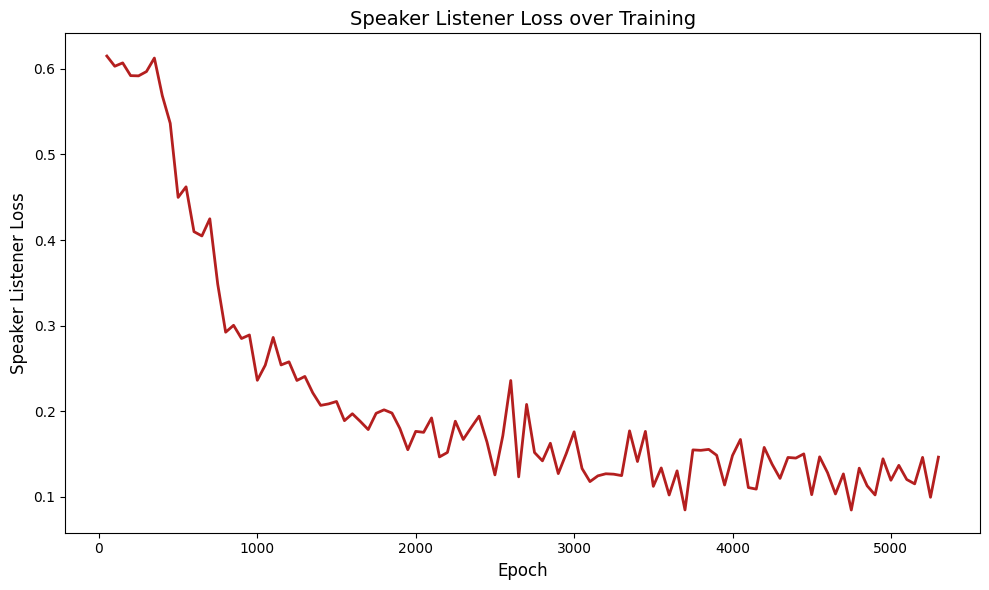

Plot saved to ../images/speaker_accuracy.png


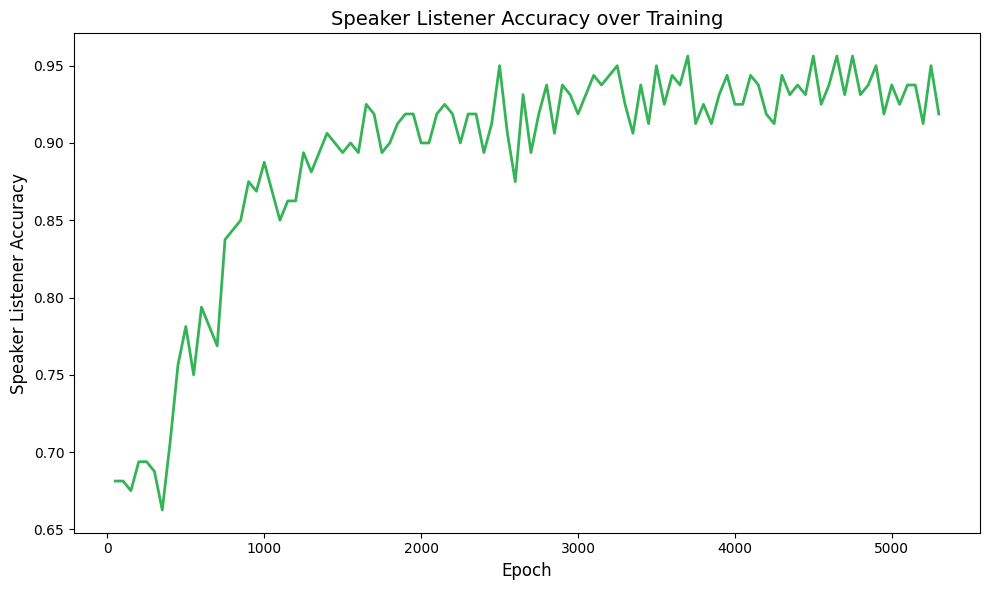

In [18]:
# Training graphs
plot_metric(losses, step_size=50, metric_name='Speaker Listener Loss', save_path='../images/speaker_loss.png')
plot_metric(accuracies, step_size=50, metric_name='Speaker Listener Accuracy', save_path='../images/speaker_accuracy.png')

### Inference

In [19]:
# Freeze the speaker-listener model parameters
for param in model.parameters():
    param.requires_grad = False

model.eval()

SpeakerListenerSystem(
  (encoder): ObjectEncoder(
    (encoder): Sequential(
      (0): Conv2d(1, 4, kernel_size=(2, 2), stride=(1, 1))
      (1): Flatten(start_dim=1, end_dim=-1)
      (2): Linear(in_features=16, out_features=6, bias=True)
    )
  )
  (speaker): Speaker(
    (speaker_net): Sequential(
      (0): Linear(in_features=35, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=32, bias=True)
      (3): ReLU()
      (4): Linear(in_features=32, out_features=12, bias=True)
    )
  )
  (listener): Listener(
    (listener_net): Sequential(
      (0): Linear(in_features=18, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=8, bias=True)
      (3): ReLU()
      (4): Linear(in_features=8, out_features=1, bias=True)
    )
  )
)

In [20]:
print("\n--- Running a test example ---")

with torch.no_grad():
    W_test, X_test_mask = dataset_splits['speaker_listener']['W'][0:1], dataset_splits['speaker_listener']['X_mask'][0:1]

    # dummy data
    # generate_batch(1, WORLD_SIZE)

    print("Test World W has 5 objects.")
    print(f"Target set X is selected by mask: {X_test_mask[0]}")


    y_test_logits, y_test_labels = model(W_test, X_test_mask)
    y_test_probs  = torch.sigmoid(y_test_logits)

    print(f"Ground truth vector: {y_test_labels.numpy().flatten()}")

    print(f"Model prediction (probabilities): {y_test_probs.numpy().flatten()}")
    print(f"Final prediction (rounded): {[round(p, 2) for p in y_test_probs.numpy().flatten()]}")


--- Running a test example ---
Test World W has 5 objects.
Target set X is selected by mask: tensor([0., 1., 1., 1., 1.])
Ground truth vector: [1. 0. 1. 1. 1.]
Model prediction (probabilities): [9.9946767e-01 3.2298624e-15 1.0000000e+00 1.0000000e+00 9.9402434e-01]
Final prediction (rounded): [np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(1.0), np.float32(0.99)]


In [21]:
# Evaluate speaker-listener on full test set
print("\n--- Evaluating speaker-listener on full test set ---")

test_losses = []
test_accuracies = []

N_TEST = len(dataset_splits['translator_test']['W'])
start_index = 0

with torch.no_grad():  # Important: no gradients during eval
    while start_index < N_TEST:
        batch_size = min(BATCH_SIZE, N_TEST - start_index)

        # Load test batch
        W_batch, X_mask_batch = load_batch(
            'translator_test', start_index, batch_size
        )

        # Predict
        test_logits, test_truth = model(W_batch, X_mask_batch)

        # Calculate loss
        loss = criterion(test_logits, test_truth)

         # Calculate accuracy for monitoring
        preds    = torch.sigmoid(test_logits) > 0.5
        accuracy = (preds.float() == test_truth).float().mean()

        # Store metrics
        test_losses.append(loss.item())
        test_accuracies.append(accuracy.item())

        start_index += batch_size

# Print overall results
print(f"Test Loss: {np.mean(test_losses):.4f}")
print(f"Test Accuracy: {np.mean(test_accuracies):.4f}")



--- Evaluating speaker-listener on full test set ---
Test Loss: 0.1298
Test Accuracy: 0.9292


### Persistence

In [22]:
# Persist the trained speaker-listener model.

torch.save({
    'model_state_dict': model.state_dict(),
    'hyperparameters': {
        'world_size': WORLD_SIZE,
        'object_feature_dimension': OBJECT_FEATURE_DIMENSION,
        'neuralese_dimension': NEURALESE_DIMENSION,
    }
}, 'speaker_listener.pt')

print("Model saved to speaker_listener.pt")


Model saved to speaker_listener.pt


### Validation
We want to check that the speaker learns the actual features of the subset with respect to the larger world, instead of some cheat like the mask positions.
We do this by testing whether the neuralese representing similar rules are closer in distance than different rules.

In [23]:
# Select 9 rules out of our total of 72
rules = ["red", "triangle", "purple or no-outline",
         "green or circle", "red and square", "triangle and slim-outline",
         "not purple", "not thick-outline", "red or no-outline"]

In [24]:
# Retrieve n examples that fit this rule
def get_world_with_rule(rule, n):
    """
    Retrieve n examples from dataset that match the given rule.

    Args:
        rule: string like "red", "circle", "not thick-outline", etc.
        n: number of examples to retrieve

    Returns:
        W_list: list of world tensors
        X_mask_list: list of mask tensors
    """
    # Use the translator train split
    rule_texts = dataset_splits['translator_train']['rule_texts']

    # Find indices that match the rule
    matched_indices = []
    for i, rt in enumerate(rule_texts):
      if rt == rule:
        matched_indices.append(i)
        if len(matched_indices) == n:
          break

    # Load the matching data
    W_list = []
    X_list = []
    for i in matched_indices:
      W, X = load_batch('translator_train', i, 1)
      W_list.append(W)
      X_list.append(X)

    return W_list, X_list

In [25]:
# Generate 100 neuralese examples for each rule
neuralese_by_rule = {}
for rule in rules:
    vectors = []
    W, X = get_world_with_rule(rule, n=100)
    for idx in range(100):
        V = model(W[idx], X[idx], return_neuralese_only=True)
        vectors.append(V)
    neuralese_by_rule[rule] = torch.cat(vectors, dim=0) # (100, neuralese_dimension)



In [26]:
# Compute within-rule and between-rule similarities
# within-rule (should be HIGH if consistent)
# between-rule (should be LOW if discriminative)

within_rule  = []
between_rule = []

for rule in rules:
  vectors = neuralese_by_rule[rule]

  # pair-wise within rule
  for i in range(100):
      for j in range(i+1, 100):
          sim = F.cosine_similarity(vectors[i], vectors[j], dim=0)
          within_rule.append(sim.item())

  # between rules
  for rule_1 in rules:
      for rule_2 in rules:
          if rule_1 != rule_2:
              rand_idx = random.randint(0, 99)
              v_1 = neuralese_by_rule[rule_1][rand_idx]
              v_2 = neuralese_by_rule[rule_2][rand_idx]
              sim = F.cosine_similarity(v_1, v_2, dim=0)
              between_rule.append(sim.item())


In [27]:
print(f"Within-rule:  {np.mean(within_rule):.3f}  ± {np.std(within_rule):.3f}")
print(f"Between-rule: {np.mean(between_rule):.3f} ± {np.std(between_rule):.3f}")

Within-rule:  0.966  ± 0.039
Between-rule: 0.939 ± 0.045


The signal is weak - only 4.3% separation. The neuralese vectors are pointing in very similar directions regardless of rule.

But this weakness might explain the ~35% translation accuracy. The translator model is trying to extract a very weak signal.

The similarity between vectors might be indicative of a dominant baseline signal.

So we will try to normalize for it.


**Centering**



In [28]:
# Collect all neuralese vectors within our test rules
all_V = []
for rule in rules:
    all_V.append(neuralese_by_rule[rule])
all_V = torch.cat(all_V, dim=0) # (num_rules (9) * 100, 12)

# Compute global mean
mean_V = all_V.mean(dim=0) # (12)

# Center all vectors
neuralese_by_rule_centered = {}
for rule in rules:
    neuralese_by_rule_centered[rule] = neuralese_by_rule[rule] - mean_V

In [30]:
# Repeat experiment with centered neuralese
within_rule  = []
between_rule = []

for rule in rules:
  vectors = neuralese_by_rule_centered[rule]

  # pair-wise within rule
  for i in range(100):
      for j in range(i+1, 100):
          sim = F.cosine_similarity(vectors[i], vectors[j], dim=0)
          within_rule.append(sim.item())

  # between rules
  for rule_1 in rules:
      for rule_2 in rules:
          if rule_1 != rule_2:
              rand_idx = random.randint(0, 99)
              v_1 = neuralese_by_rule_centered[rule_1][rand_idx]
              v_2 = neuralese_by_rule_centered[rule_2][rand_idx]
              sim = F.cosine_similarity(v_1, v_2, dim=0)
              between_rule.append(sim.item())

In [31]:
print(f"Within-rule:  {np.mean(within_rule):.3f}  ± {np.std(within_rule):.3f}")
print(f"Between-rule: {np.mean(between_rule):.3f} ± {np.std(between_rule):.3f}")

Within-rule:  0.351  ± 0.528
Between-rule: -0.043 ± 0.551


This shows that the rule information IS consistently encoded in the neuralese, but is hidden under a massive baseline signal. After removing the baseline, the rules separate beautifully.

So the translator had weak prediction power because it was drowning in the baseline signal...
We can now go on to train the translator on centered neuralese.